# Task 3
Execute the following code, then add additional words to see where they get placed in the Word Embeddings Cloud.

In [ ]:
# !pip install sentence_transformers

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


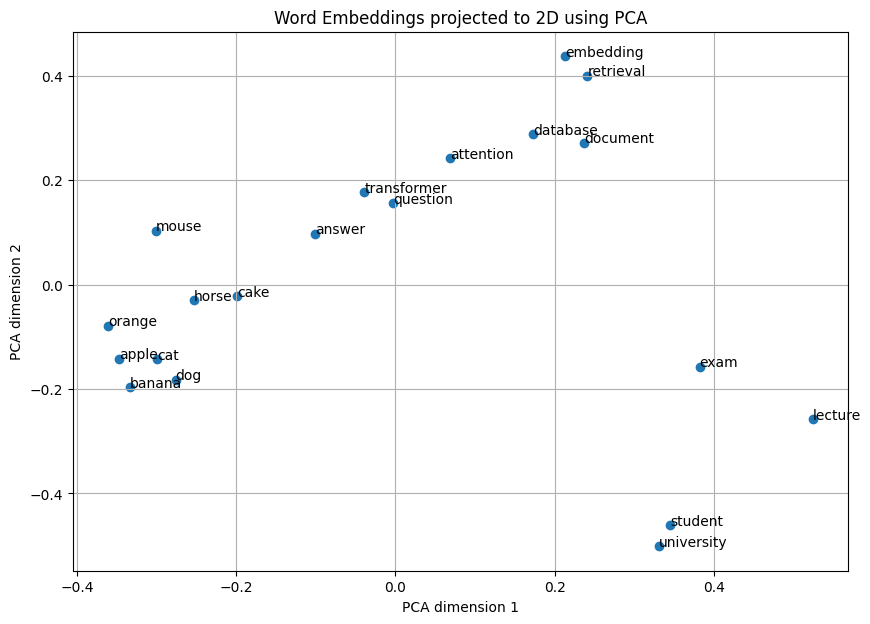

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2",
    token=False
)

words = [
    "dog", "cat", "horse", "mouse",
    "apple", "banana", "orange", "cake",
    "university", "lecture", "exam", "student",
    "transformer", "attention", "embedding", "retrieval",
    "database", "document", "question", "answer"
]

embeddings = model.encode(words)

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

plt.figure(figsize=(10, 7))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1])

for i, word in enumerate(words):
    plt.annotate(word, (embeddings_2d[i, 0], embeddings_2d[i, 1]))

plt.title("Word Embeddings projected to 2D using PCA")
plt.xlabel("PCA dimension 1")
plt.ylabel("PCA dimension 2")
plt.grid(True)
plt.show()

In [7]:
from IPython.display import clear_output

cloud_words = []
cloud_embeddings = []

# Use a fixed PCA basis from the larger vocabulary above
pca_fixed = PCA(n_components=2)
pca_fixed.fit(embeddings)

def add_word(word):
    word = word.strip()

    if not word:
        print("Please enter a word.")
        return

    if word in cloud_words:
        print(f"'{word}' is already in the cloud.")
        return

    emb = model.encode([word])[0]

    cloud_words.append(word)
    cloud_embeddings.append(emb)

    clear_output(wait=True)

    X = np.array(cloud_embeddings)
    X_2d = pca_fixed.transform(X)

    plt.figure(figsize=(10, 7))
    plt.scatter(X_2d[:, 0], X_2d[:, 1])

    for i, w in enumerate(cloud_words):
        plt.annotate(w, (X_2d[i, 0], X_2d[i, 1]))

    plt.title("Growing Embedding Cloud")
    plt.xlabel("PCA dimension 1")
    plt.ylabel("PCA dimension 2")
    plt.grid(True)
    plt.show()

    print("Words in cloud:", cloud_words)

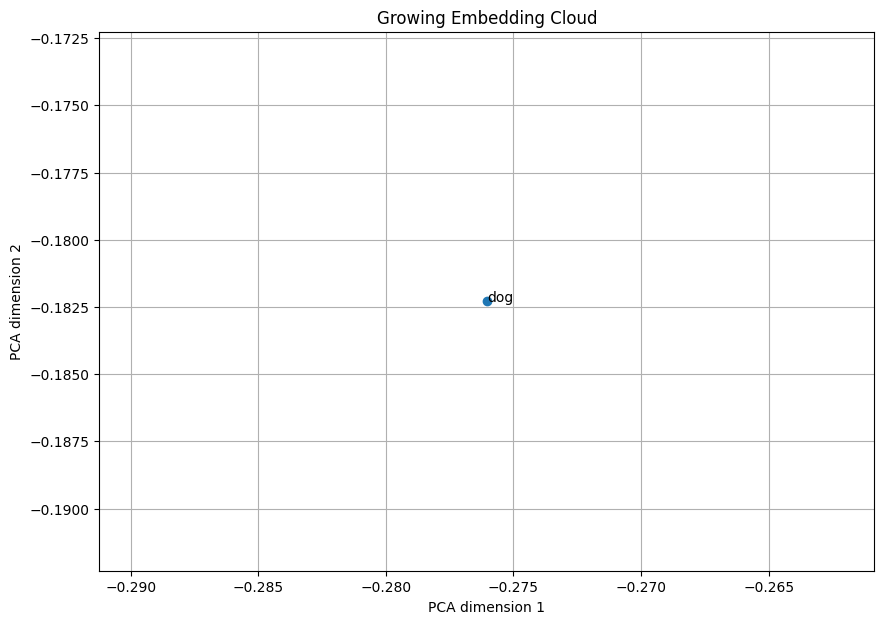

Words in cloud: ['dog']


In [8]:
add_word("dog")


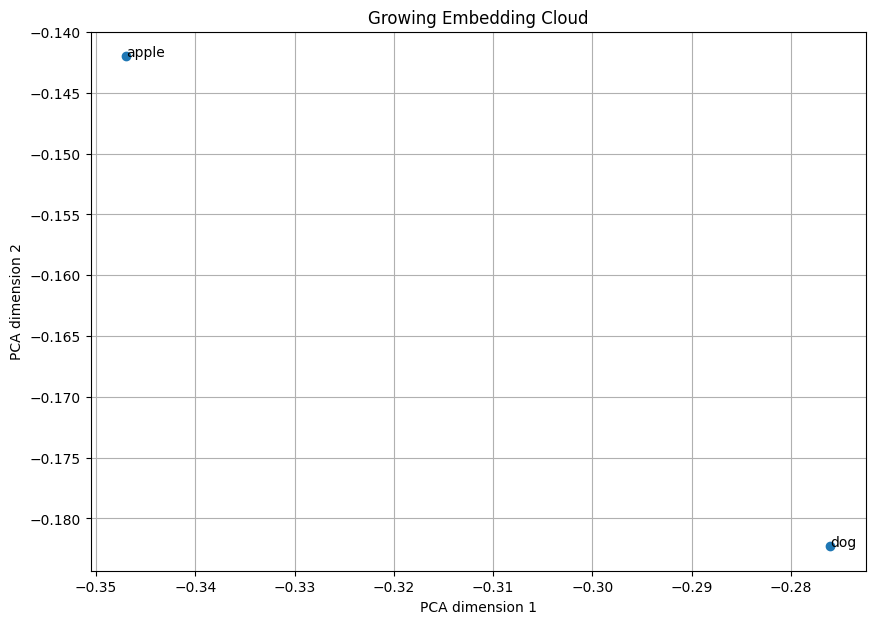

Words in cloud: ['dog', 'apple']


In [9]:
add_word("apple")


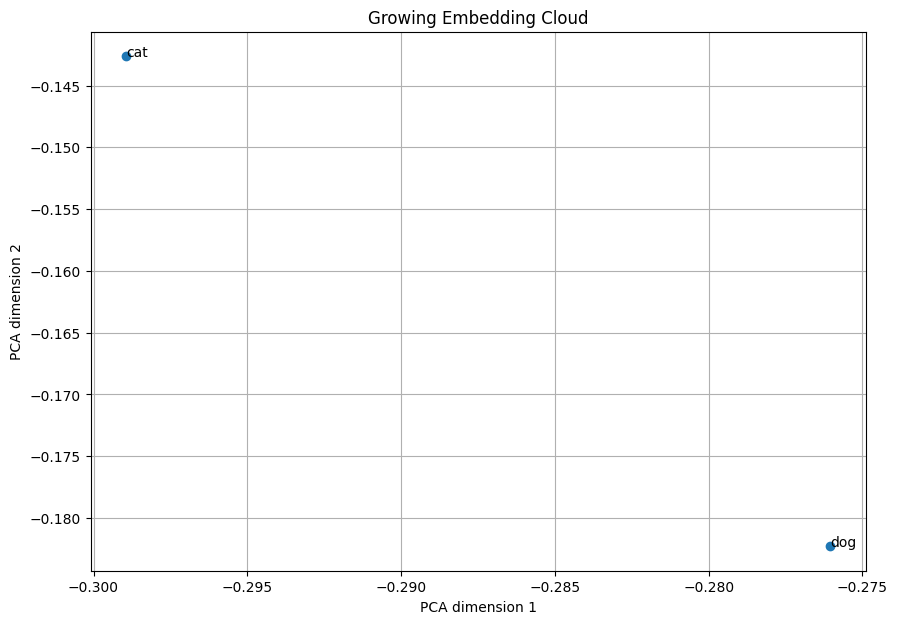

Words in cloud: ['dog', 'cat']


In [9]:
add_word("cat")


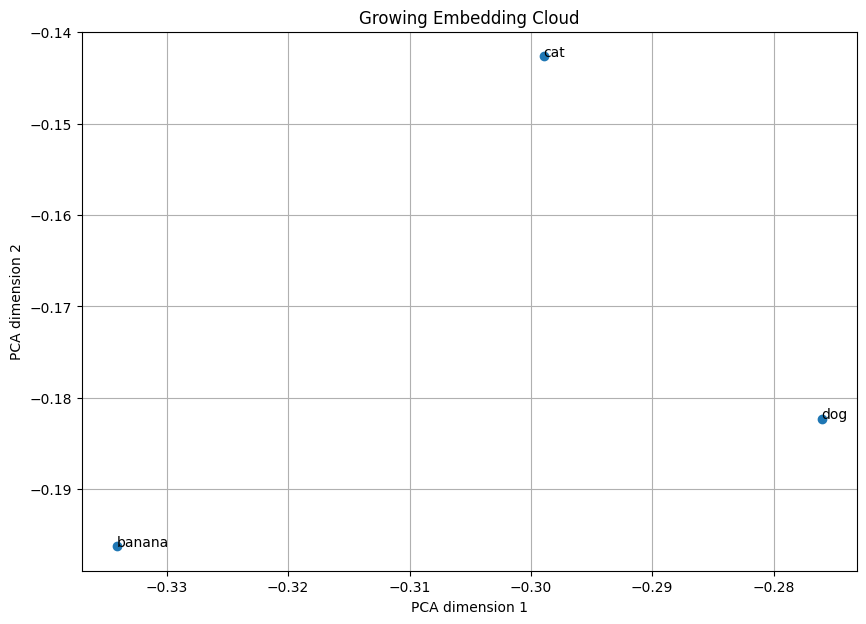

Words in cloud: ['dog', 'cat', 'banana']


In [10]:
add_word("banana")


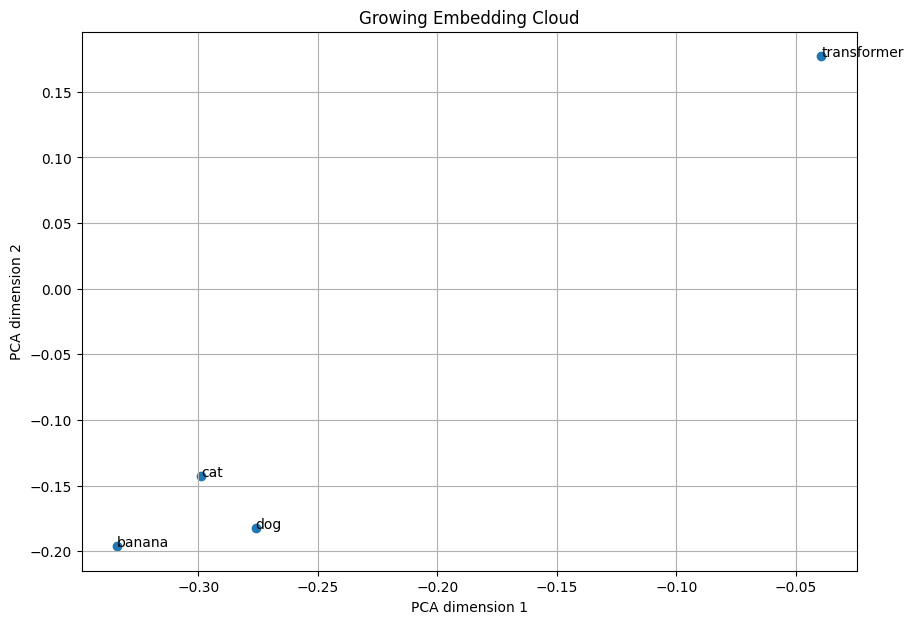

Words in cloud: ['dog', 'cat', 'banana', 'transformer']


In [11]:
add_word("transformer")


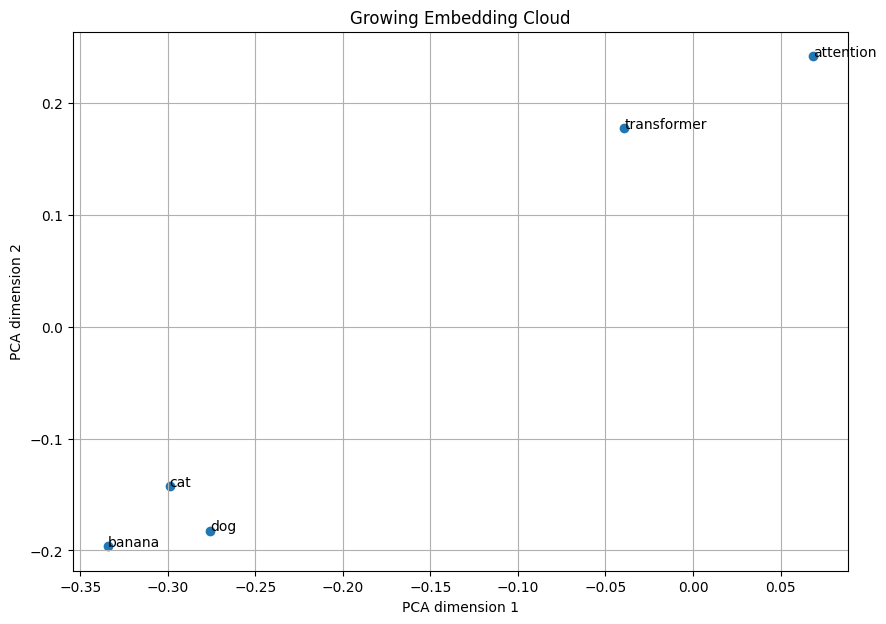

Words in cloud: ['dog', 'cat', 'banana', 'transformer', 'attention']


In [12]:
add_word("attention")


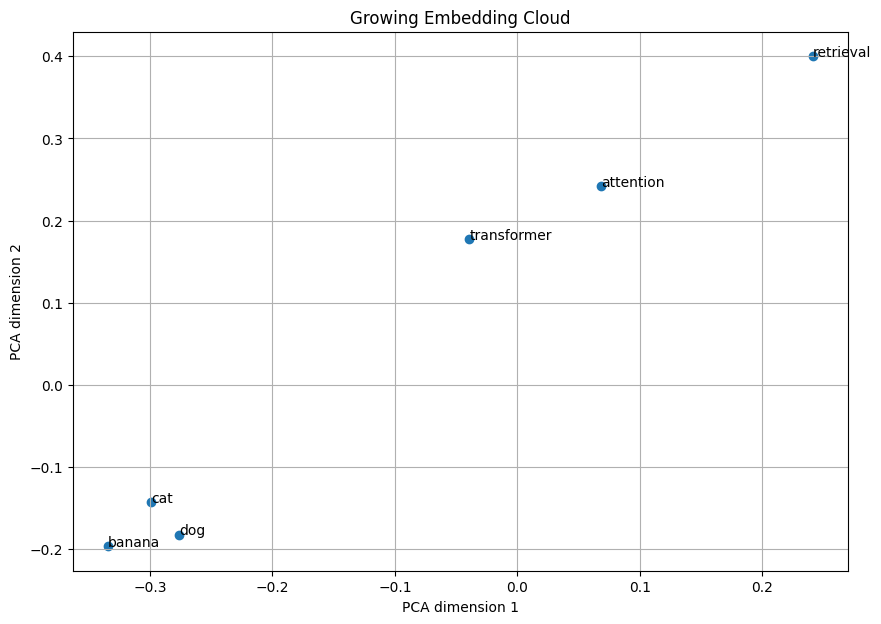

Words in cloud: ['dog', 'cat', 'banana', 'transformer', 'attention', 'retrieval']


In [13]:
add_word("retrieval")


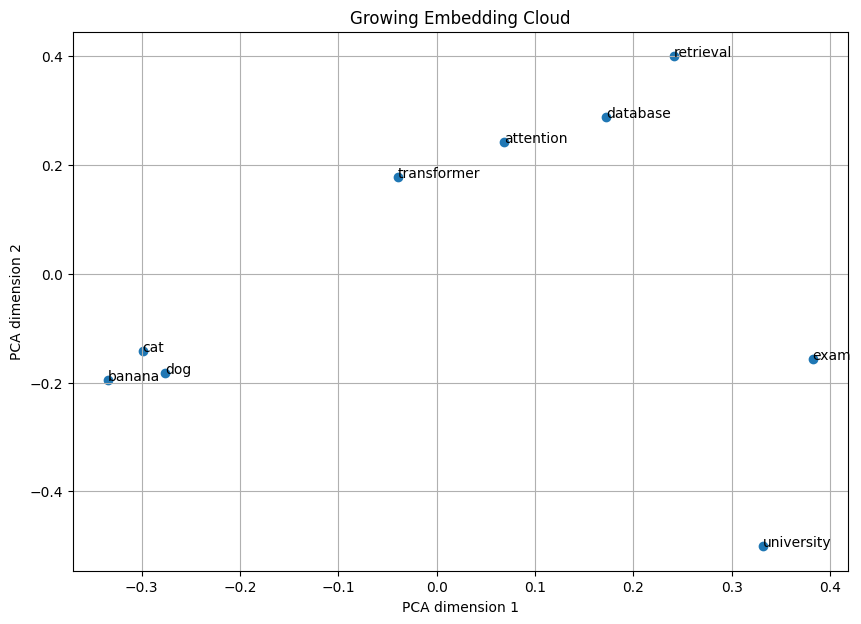

Words in cloud: ['dog', 'cat', 'banana', 'transformer', 'attention', 'retrieval', 'database', 'university', 'exam']


In [14]:
add_word("database")
add_word("university")
add_word("exam")

a) Find at least one word that can have two different meanings and thus might get placed in a weird position.

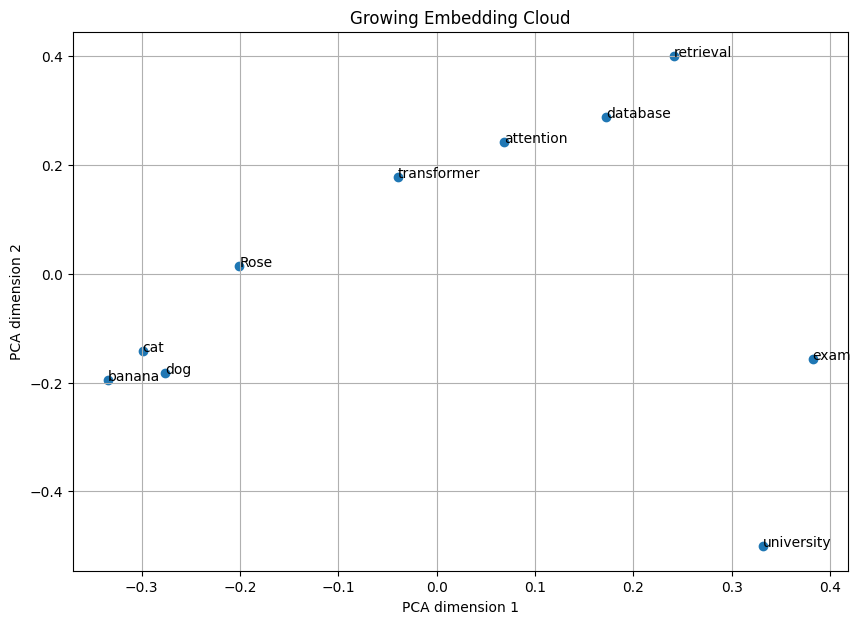

Words in cloud: ['dog', 'cat', 'banana', 'transformer', 'attention', 'retrieval', 'database', 'university', 'exam', 'Rose']


In [16]:
# Add a word below
add_word("Rose")

b) Find two words that are different but can have similar contexts so that they might get placed closely together.

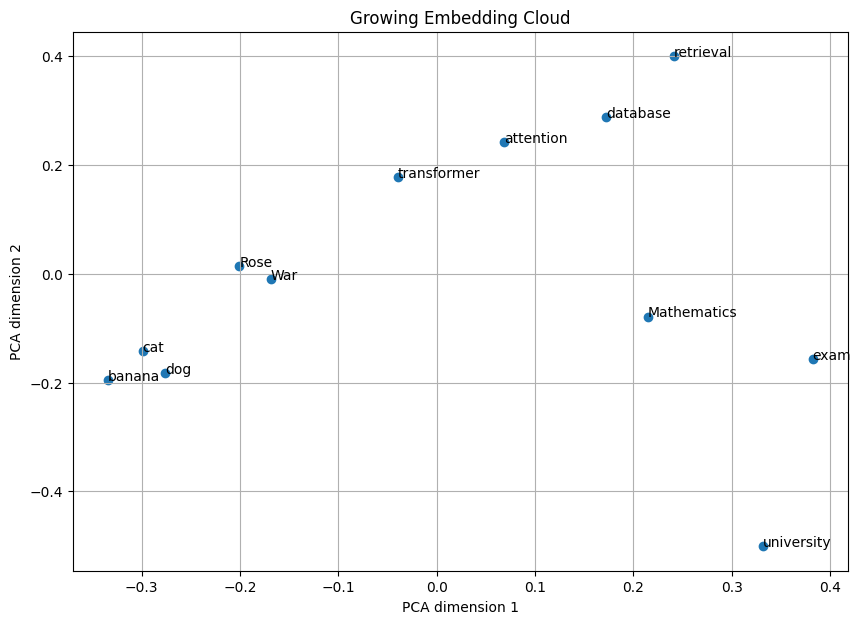

Words in cloud: ['dog', 'cat', 'banana', 'transformer', 'attention', 'retrieval', 'database', 'university', 'exam', 'Rose', 'War', 'Mathematics']


In [17]:
# Add more words below
add_word("War")
add_word("Mathematics")

c) Add additional words that you want to integrate into the word cloud.

In [ ]:
# Add a word below
add_word("")

# Task 4
In this task, you will experiment with RAG.

In [17]:
import logging
import numpy as np
import matplotlib.pyplot as plt

from transformers.utils import logging as hf_logging
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

logging.getLogger("sentence_transformers").setLevel(logging.ERROR)
hf_logging.set_verbosity_error()

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

test = model.encode(["dog", "cat", "transformer"])
print("Model loaded successfully.")
print("Test embedding shape:", test.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model loaded successfully.
Test embedding shape: (3, 384)


In [19]:
chunks = [
    "The lecture introduces transformers and attention mechanisms.",
    "Retrieval augmented generation uses external documents as context.",
    "The exam contains conceptual questions and small calculations.",
    "Neural networks are trained using gradient descent.",
    "Recurrent neural networks process sequential data.",
    "Embeddings represent words or texts as high-dimensional vectors.",
]

chunk_embeddings = model.encode(chunks)

print("Chunk embeddings shape:", chunk_embeddings.shape)

Chunk embeddings shape: (6, 384)


In [20]:
def retrieve_and_plot(query, top_k=3):
    query_embedding = model.encode([query])

    similarities = cosine_similarity(query_embedding, chunk_embeddings)[0]

    top_indices = np.argsort(similarities)[::-1][:top_k]

    print("Query:")
    print(query)
    print("\nTop retrieved chunks:")

    for rank, idx in enumerate(top_indices, start=1):
        print(f"{rank}. Score: {similarities[idx]:.3f}")
        print(chunks[idx])
        print()

    all_embeddings = np.vstack([chunk_embeddings, query_embedding])

    pca = PCA(n_components=2)
    all_2d = pca.fit_transform(all_embeddings)

    chunk_2d = all_2d[:-1]
    query_2d = all_2d[-1]

    plt.figure(figsize=(9, 6))

    plt.scatter(chunk_2d[:, 0], chunk_2d[:, 1], label="Document chunks")
    plt.scatter(query_2d[0], query_2d[1], marker="x", s=120, label="Query")

    for i, chunk in enumerate(chunks):
        plt.annotate(f"Chunk {i+1}", (chunk_2d[i, 0], chunk_2d[i, 1]))

    plt.annotate("Query", (query_2d[0], query_2d[1]))

    for idx in top_indices:
        plt.plot(
            [query_2d[0], chunk_2d[idx, 0]],
            [query_2d[1], chunk_2d[idx, 1]],
            linestyle="--"
        )

    plt.title("Query and Retrieved Chunks in Embedding Space")
    plt.xlabel("PCA Dimension 1")
    plt.ylabel("PCA Dimension 2")
    plt.legend()
    plt.grid(True)
    plt.show()

a) Enter three different queries that can be answered with the help of the RAG system.

Query:
How does RAG use external documents?

Top retrieved chunks:
1. Score: 0.408
Retrieval augmented generation uses external documents as context.

2. Score: 0.213
Embeddings represent words or texts as high-dimensional vectors.

3. Score: 0.205
The exam contains conceptual questions and small calculations.



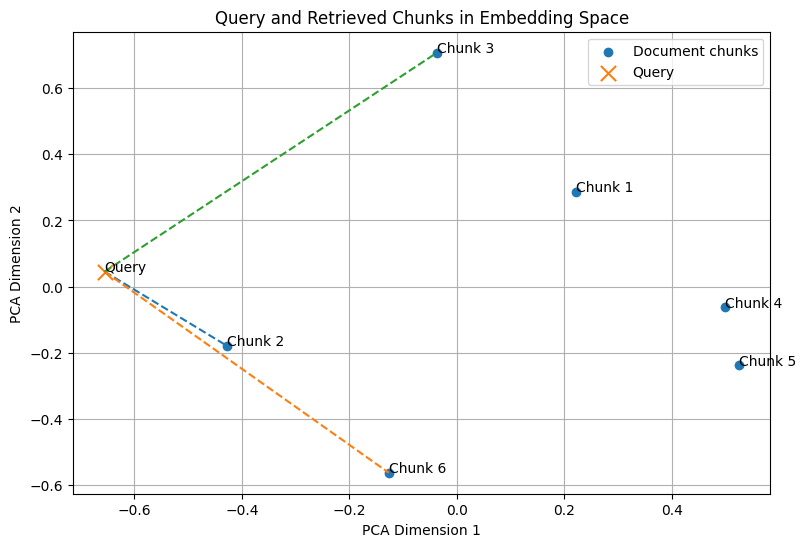

In [21]:
# for example:
retrieve_and_plot("How does RAG use external documents?")
# Add more...

b) Add additional information about a topic of your choice to the RAG system that the system can use to answer queries.

In [ ]:
chunks = [
    "The lecture introduces transformers and attention mechanisms.",
    "Retrieval augmented generation uses external documents as context.",
    "The exam contains conceptual questions and small calculations.",
    "Neural networks are trained using gradient descent.",
    "Recurrent neural networks process sequential data.",
    "Embeddings represent words or texts as high-dimensional vectors.",
]

chunk_embeddings = model.encode(chunks)

print("Chunk embeddings shape:", chunk_embeddings.shape)

Chunk embeddings shape: (6, 384)


c) Create three queries that can be answered with the help of your adapted RAG system.

Query:
How does RAG use external documents?

Top retrieved chunks:
1. Score: 0.408
Retrieval augmented generation uses external documents as context.

2. Score: 0.213
Embeddings represent words or texts as high-dimensional vectors.

3. Score: 0.205
The exam contains conceptual questions and small calculations.



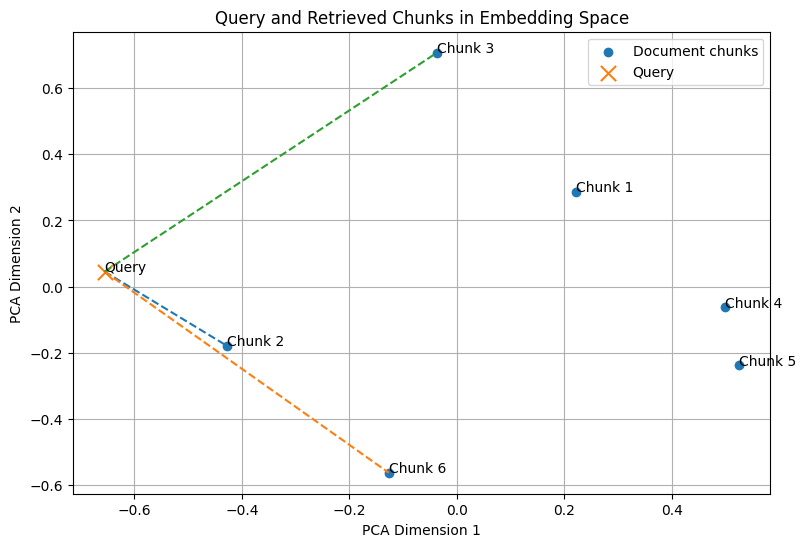

In [ ]:
retrieve_and_plot("")
# Add more...